In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
excel_file = pd.ExcelFile("../../data/bpic19.xlsx", engine="openpyxl")

df = pd.concat(
    [
        pd.read_excel(
            excel_file,
            keep_default_na=False,
            dtype={
                "case:concept:name": "string",
                "concept:name": "string",
                "case:Spend area text": "string",
                "case:Document Type": "string",
                "case:Sub spend area text": "string",
                "case:Purch. Doc. Category name": "string",
                "case:Item Type": "string",
                "case:Item Category": "string",
                "case:Spend classification text": "string",
                "case:Source": "string",
                "case:GR-Based Inv. Verif.": "string",
                "case:Goods Receipt": "string",
                "Cumulative net worth (EUR)": "float32",
                "time_delta": "float32",
            }
        )
        for sheet in excel_file.sheet_names
    ],
    ignore_index=True,
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,Cumulative net worth (EUR),case:Document Type,case:GR-Based Inv. Verif.,case:Goods Receipt,case:Item Category,case:Item Type,case:Purch. Doc. Category name,case:Source,case:Spend area text,case:Spend classification text,case:Sub spend area text,concept:name,time_delta
0,2000000000_00001,2018-01-02 12:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,SRM: Created,0.0
1,2000000000_00001,2018-01-02 13:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,SRM: Complete,3600.0
2,2000000000_00001,2018-01-02 13:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,SRM: Awaiting Approval,0.0
3,2000000000_00001,2018-01-02 13:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,SRM: Document Completed,0.0
4,2000000000_00001,2018-01-02 13:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,SRM: In Transfer to Execution Syst.,0.0
5,2000000000_00001,2018-01-02 13:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,SRM: Ordered,0.0
6,2000000000_00001,2018-01-02 13:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,SRM: Change was Transmitted,0.0
7,2000000000_00001,2018-01-02 13:53:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,Create Purchase Order Item,0.0
8,2000000000_00001,2018-01-02 22:59:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,Vendor creates invoice,32760.0
9,2000000000_00001,2018-03-06 06:44:00,298.0,EC Purchase order,False,True,"3-way match, invoice before GR",Standard,Purchase order,sourceSystemID_0000,CAPEX & SOCS,NPR,Facility Management,Record Goods Receipt,5384700.0


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['Cumulative net worth (EUR)', 'case:Document Type', 'case:GR-Based Inv. Verif.', 'case:Goods Receipt', 'case:Item Category', 'case:Item Type', 'case:Purch. Doc. Category name', 'case:Source', 'case:Spend area text', 'case:Spend classification text', 'case:Sub spend area text', 'concept:name', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
case:Document Type             categorical    case     yes    ['EC Purchase order', 'Framework order', 'Standard PO'] N/A        data_derived        
case:GR-Based Inv. Verif.      categorical    case     yes    ['False', 'True

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

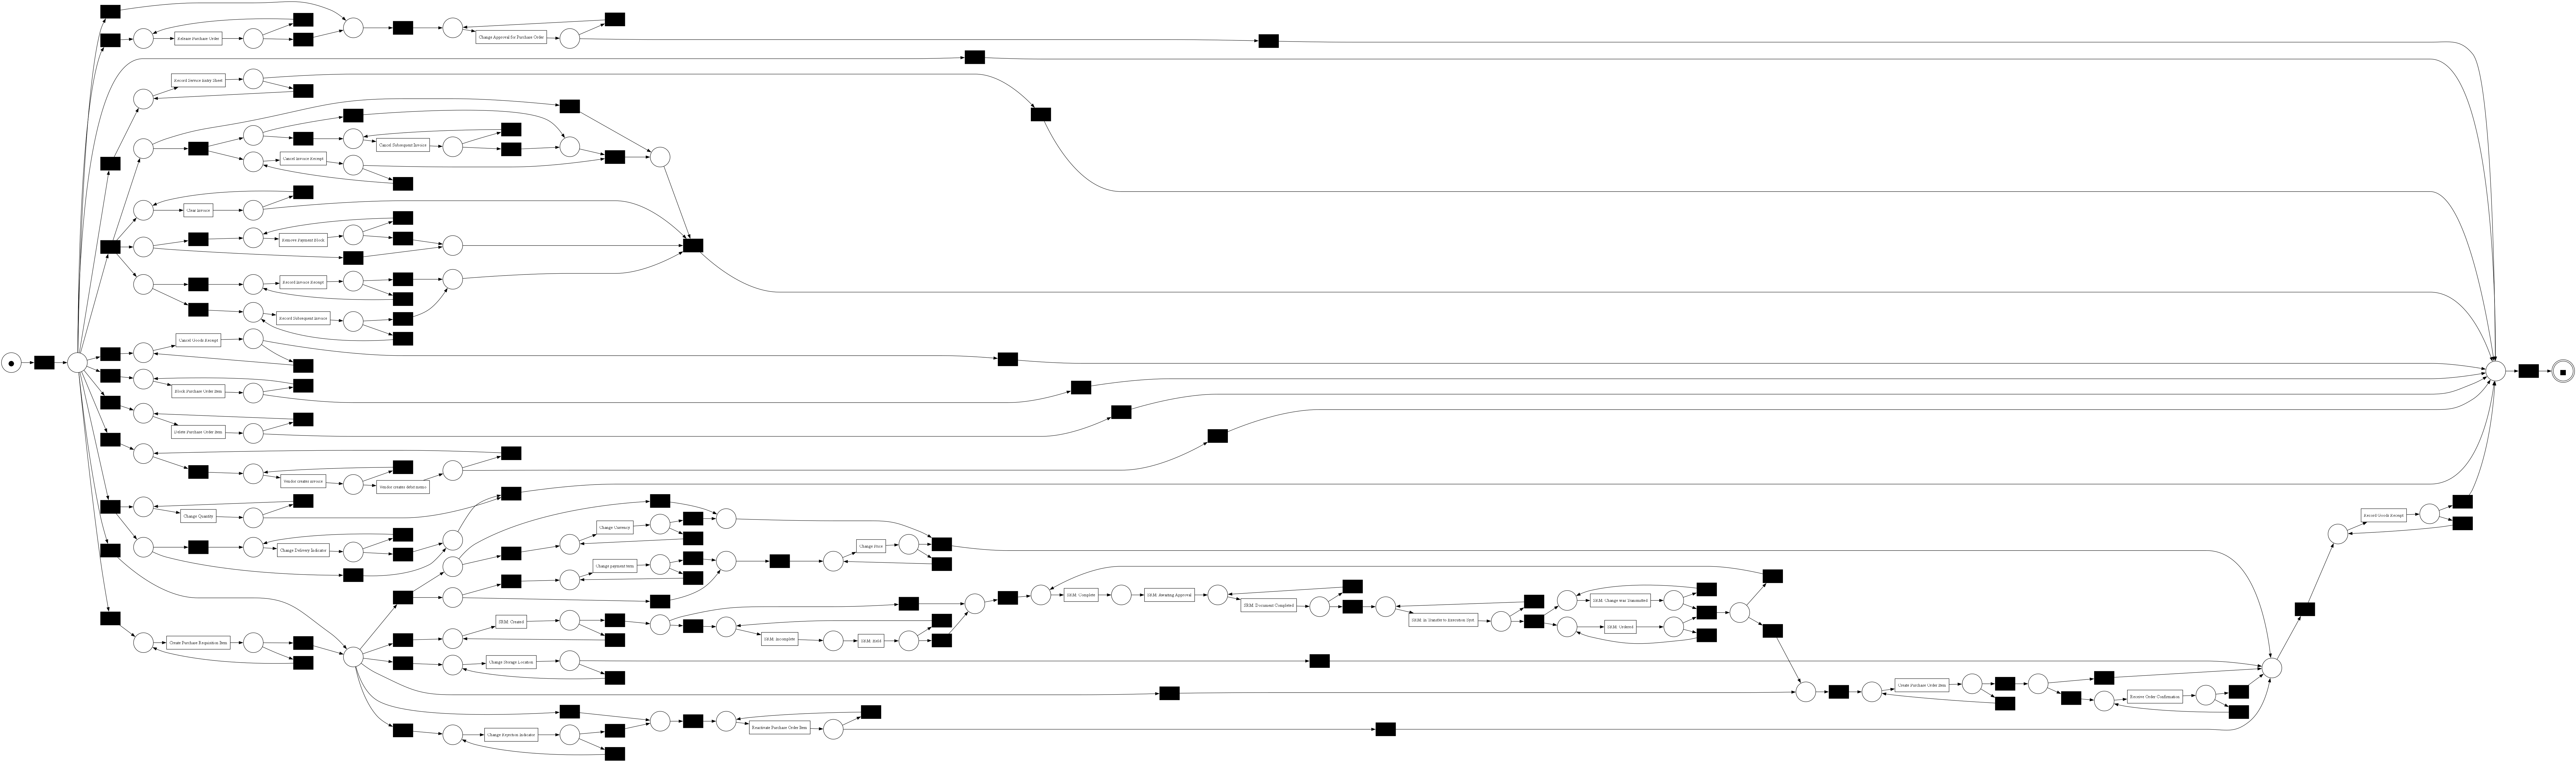

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[{'Change Delivery Indicator', 'Change Quantity'},
 {'Cancel Invoice Receipt',
  'Cancel Subsequent Invoice',
  'Clear Invoice',
  'Record Invoice Receipt',
  'Record Subsequent Invoice',
  'Remove Payment Block'},
 {'Cancel Invoice Receipt', 'Cancel Subsequent Invoice'},
 {'Change Currency', 'Change Price', 'Change payment term'},
 {'SRM: Change was Transmitted', 'SRM: Ordered'}]

In [15]:
engine.branching_sets

[{'Block Purchase Order Item',
  'Cancel Goods Receipt',
  'Cancel Invoice Receipt',
  'Cancel Subsequent Invoice',
  'Change Approval for Purchase Order',
  'Change Currency',
  'Change Delivery Indicator',
  'Change Price',
  'Change Quantity',
  'Change Rejection Indicator',
  'Change Storage Location',
  'Change payment term',
  'Clear Invoice',
  'Create Purchase Order Item',
  'Create Purchase Requisition Item',
  'Delete Purchase Order Item',
  'Reactivate Purchase Order Item',
  'Receive Order Confirmation',
  'Record Goods Receipt',
  'Record Invoice Receipt',
  'Record Service Entry Sheet',
  'Record Subsequent Invoice',
  'Release Purchase Order',
  'Remove Payment Block',
  'SRM: Awaiting Approval',
  'SRM: Change was Transmitted',
  'SRM: Complete',
  'SRM: Created',
  'SRM: Document Completed',
  'SRM: Held',
  'SRM: In Transfer to Execution Syst.',
  'SRM: Incomplete',
  'SRM: Ordered',
  'Vendor creates debit memo',
  'Vendor creates invoice'},
 {'Record Invoice Receipt

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/bpic19-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

500

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,4508042805_00010,6,0,3,1,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Create Purchase O...",{2: {'Record Goods Receipt'}},68515,45938,10,window_variant_mixed
1,0,4508044035_00320,8,0,3,1,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Create Purchase O...",{2: {'Record Goods Receipt'}},68515,45938,10,window_variant_mixed
2,0,4507029240_00300,10,0,3,1,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Create Purchase O...",{2: {'Record Goods Receipt'}},68515,45938,10,window_variant_mixed
3,0,4507017655_00360,12,0,3,1,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Create Purchase O...",{2: {'Record Goods Receipt'}},68515,45938,10,window_variant_mixed
4,0,4507037320_00020,14,0,3,1,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Create Purchase O...",{2: {'Record Goods Receipt'}},68515,45938,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

8

In [25]:
len(exp_df_mul)

500

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,4508042805_00010,6,0,3,2,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Receive Order Con...","{1: {'Receive Order Confirmation'}, 2: {'Creat...",68515,2343,10,window_variant_mixed
1,0,4508044035_00320,8,0,3,2,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Receive Order Con...","{1: {'Receive Order Confirmation'}, 2: {'Creat...",68515,2343,10,window_variant_mixed
2,0,4507029240_00300,10,0,3,2,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Receive Order Con...","{1: {'Receive Order Confirmation'}, 2: {'Creat...",68515,2343,10,window_variant_mixed
3,0,4507017655_00360,12,0,3,2,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Receive Order Con...","{1: {'Receive Order Confirmation'}, 2: {'Creat...",68515,2343,10,window_variant_mixed
4,0,4507037320_00020,14,0,3,2,"(Create Purchase Order Item, Create Purchase O...","(Create Purchase Order Item, Receive Order Con...","{1: {'Receive Order Confirmation'}, 2: {'Creat...",68515,2343,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/500 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,4508042805_00010,6,1,2,0.418633,0.442266,0.395,0.503571,0.253333,...,0.469814,0.000000,0.184100,0.3,0.068199,0.285714,0.0,0.000000,0.0,0.0
1,0,4508044035_00320,8,1,2,0.421610,0.483219,0.360,0.464286,0.378947,...,0.437218,0.315789,0.050000,0.1,0.000000,0.071429,0.0,0.000000,0.0,0.0
2,0,4507029240_00300,10,1,4,0.361325,0.337649,0.385,0.435714,0.369565,...,0.469255,0.347826,0.050000,0.1,0.000000,0.071429,0.0,0.926663,0.0,1.0
3,0,4507017655_00360,12,1,6,0.420061,0.540123,0.300,0.432143,0.385185,...,0.445515,0.296296,0.006361,0.0,0.012723,0.142857,0.0,0.918074,0.0,1.0
4,0,4507037320_00020,14,1,6,0.330709,0.366418,0.295,0.353571,0.506452,...,0.516129,0.516129,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,49,4507026467_00001,40,1,0,0.275012,0.220025,0.330,0.490625,0.045783,...,0.244638,0.000000,0.025888,0.0,0.051775,0.218750,0.0,0.000000,0.0,0.0
463,49,4507032796_00001,42,1,0,0.358304,0.376609,0.340,0.573437,0.001149,...,0.129990,0.000000,0.036240,0.0,0.072480,0.093750,0.0,0.000000,0.0,0.0
464,49,4507024372_00001,44,1,0,0.296579,0.273158,0.320,0.543750,0.010989,...,0.162340,0.000000,0.006090,0.0,0.012180,0.156250,0.0,0.000000,0.0,0.0
465,49,4507026083_00001,48,1,0,0.323385,0.351769,0.295,0.556250,0.049495,...,0.049350,0.000000,0.018100,0.0,0.036200,0.031250,0.0,0.000000,0.0,0.0


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/500 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,4508042805_00010,6,2,2,0.358932,0.417864,0.300,0.375000,0.591667,...,0.887226,0.277778,0.050000,0.1,0.000000,0.083333,0.476115,0.474914,0.500000,0.500000
1,0,4508044035_00320,8,2,2,0.342965,0.385929,0.300,0.341667,0.634091,...,1.379943,0.500000,0.150000,0.3,0.000000,0.250000,0.479943,0.473005,0.500000,0.500000
2,0,4507029240_00300,10,2,4,0.231700,0.233400,0.230,0.283333,0.521154,...,1.136777,0.423077,0.062378,0.1,0.024757,0.166667,0.484655,0.468063,0.500000,0.500000
3,0,4507017655_00360,12,2,6,0.366316,0.417632,0.315,0.362500,0.458333,...,1.028417,0.300000,0.050000,0.1,0.000000,0.083333,0.595083,0.578248,0.500000,0.500000
4,0,4507037320_00020,14,2,6,0.273336,0.256672,0.290,0.320833,0.610294,...,1.286755,0.441176,0.194273,0.1,0.288546,0.166667,0.484639,0.468719,0.500000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,49,4507025254_00280,12,4,6,0.339321,0.333643,0.345,0.447222,0.477778,...,1.074919,0.305556,0.193038,0.2,0.186075,0.277778,0.298548,0.915784,0.333333,1.000000
479,49,4507026740_00190,12,4,6,0.317570,0.310139,0.325,0.488889,0.518056,...,1.348699,0.305556,0.240495,0.4,0.080991,0.500000,0.302648,0.908829,0.333333,1.000000
480,49,4507008834_00010,14,4,8,0.402939,0.330879,0.475,0.558333,0.293750,...,0.990244,0.275000,0.133310,0.2,0.066620,0.277778,0.304156,0.948351,0.333333,1.000000
481,49,4507010883_00190,14,4,8,0.329152,0.288304,0.370,0.455556,0.462500,...,1.246892,0.425000,0.111266,0.1,0.122532,0.166667,0.543960,0.914773,0.666666,1.000000


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()